# Практичне завдання 2: Логістична регресія та федеративне навчання

Датасет: Dry Bean Dataset (UCI / Kaggle), файл `data/dry_bean.csv`.
Задача: багатокласова класифікація сорту квасолі (7 класів) за фізичними характеристиками зерна.

**Чому цей датасет підходить для федеративного навчання:** дані природно уявити як виміри з кількох різних
сортувальних ліній або лабораторій. Кожна лабораторія має власні знімки зерен (локальні дані), не хоче
передавати їх іншим, але всі хочуть спільну модель. Датасет достатньо великий (13611 прикладів), щоб
розділити його між кількома клієнтами, і має 7 класів з природним дисбалансом, тому на ньому добре видно
ефекти Non-IID розподілу.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
                             log_loss, confusion_matrix)

np.random.seed(42)
SEED = 42

## Етап 1. Дослідження даних та попередня обробка

### 1.1 Первинний аналіз

In [2]:
df = pd.read_csv('data/dry_bean.csv')
print('Розмір:', df.shape)
df.head()

Розмір: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [3]:
# Типи ознак та пропущені значення
print(df.dtypes.value_counts())
print('Пропущених значень:', df.isna().sum().sum())

float64    14
int64       2
str         1
Name: count, dtype: int64
Пропущених значень: 0


Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Частки класів:
Class
DERMASON    0.261
SIRA        0.194
SEKER       0.149
HOROZ       0.142
CALI        0.120
BARBUNYA    0.097
BOMBAY      0.038
Name: count, dtype: float64


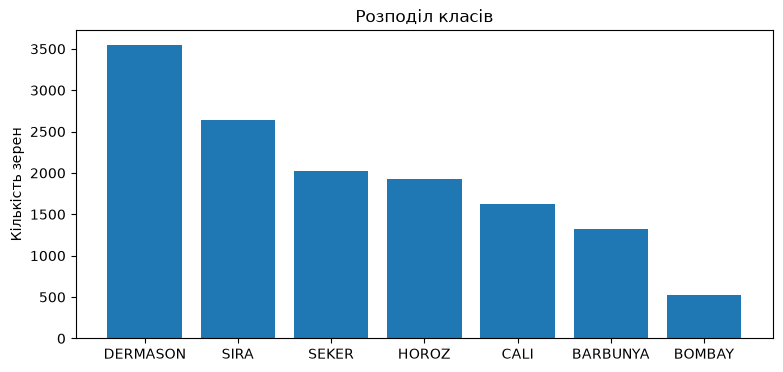

In [4]:
# Розподіл цільової змінної
counts = df['Class'].value_counts()
print(counts)
print('\nЧастки класів:')
print((counts / len(df)).round(3))

plt.figure(figsize=(9, 4))
plt.bar(counts.index, counts.values)
plt.ylabel('Кількість зерен')
plt.title('Розподіл класів')
plt.show()

In [5]:
# Основні статистики числових ознак
features_all = [c for c in df.columns if c != 'Class']
df[features_all].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.285,29324.096,20420.000,36328.000,44652.000,61332.000,254616.000
Perimeter,13611.0,855.283,214.290,524.736,703.523,794.941,977.213,1985.370
MajorAxisLength,13611.0,320.142,85.694,183.601,253.304,296.883,376.495,738.860
MinorAxisLength,13611.0,202.271,44.970,122.513,175.848,192.432,217.032,460.198
AspectRation,13611.0,1.583,0.247,1.025,1.432,1.551,1.707,2.430
Eccentricity,13611.0,0.751,0.092,0.219,0.716,0.764,0.810,0.911
ConvexArea,13611.0,53768.200,29774.916,20684.000,36714.500,45178.000,62294.000,263261.000
EquivDiameter,13611.0,253.064,59.177,161.244,215.068,238.438,279.446,569.374
Extent,13611.0,0.750,0.049,0.555,0.719,0.760,0.787,0.866
Solidity,13611.0,0.987,0.005,0.919,0.986,0.988,0.990,0.995


**Висновки EDA:**
- 13611 зерен, 16 числових ознак і 1 текстова колонка `Class`. Пропущених значень немає.
- Класи незбалансовані: найбільший DERMASON (3546 зерен, 26%), найменший BOMBAY (522 зерна, 3.8%),
  різниця майже в 7 разів. Через це не можна орієнтуватись лише на accuracy: модель може ігнорувати
  рідкісні класи і все одно мати високу точність. Тому далі рахуємо ще macro-F1 і balanced accuracy.
- Ознаки мають дуже різний масштаб: `Area` вимірюється десятками тисяч пікселів, а `ShapeFactor2` має
  порядок 0.001. Потрібна стандартизація.
- Категоріальних ознак немає, тільки цільова змінна є текстовою.

### 1.2 Кореляції між ознаками

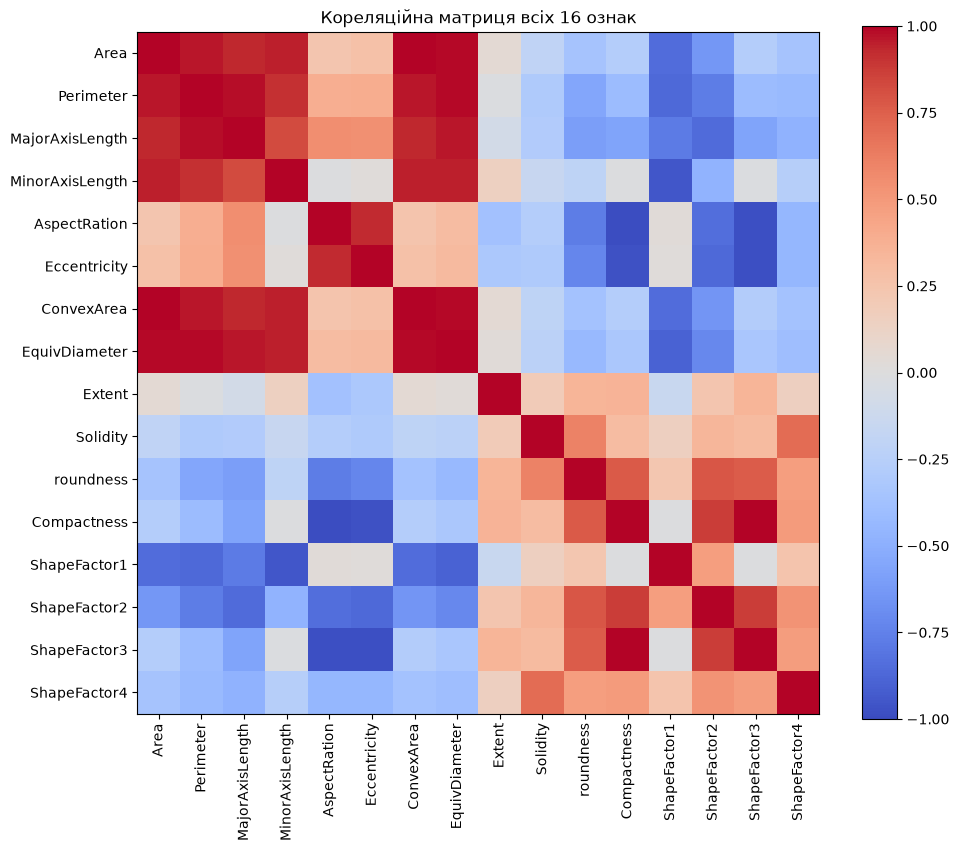

In [6]:
corr_all = df[features_all].corr()

plt.figure(figsize=(11, 9))
plt.imshow(corr_all, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(features_all)), features_all, rotation=90)
plt.yticks(range(len(features_all)), features_all)
plt.title('Кореляційна матриця всіх 16 ознак')
plt.show()

In [7]:
# Пари ознак із дуже сильною кореляцією
pairs = []
for i in range(len(features_all)):
    for j in range(i + 1, len(features_all)):
        c = corr_all.iloc[i, j]
        if abs(c) > 0.95:
            pairs.append((features_all[i], features_all[j], round(c, 3)))
pd.DataFrame(pairs, columns=['Ознака 1', 'Ознака 2', 'Кореляція'])

,Ознака 1,Ознака 2,Кореляція
0,Area,Perimeter,0.967
1,Area,MinorAxisLength,0.952
2,Area,ConvexArea,1.000
3,Area,EquivDiameter,0.985
4,Perimeter,MajorAxisLength,0.977
5,Perimeter,ConvexArea,0.968
6,Perimeter,EquivDiameter,0.991
7,MajorAxisLength,EquivDiameter,0.962
8,MinorAxisLength,ConvexArea,0.951
9,AspectRation,Compactness,-0.988


**Висновок.** У датасеті багато майже дубльованих ознак. Це очікувано: `Area`, `Perimeter`, `ConvexArea`,
`EquivDiameter`, `MajorAxisLength` це різні способи виміряти розмір того самого зерна, а `AspectRation`,
`Eccentricity`, `Compactness`, `ShapeFactor3` різні способи виміряти витягнутість. Кореляції доходять до 0.99.

Така мультиколінеарність не ламає передбачення, але робить ваги нестабільними і важкими для інтерпретації,
а також дає зайві обчислення й зайвий трафік у федеративному навчанні (більше параметрів передається
між клієнтами і сервером). Тому частину ознак приберемо.

### 1.3 Розбиття вибірки

За вимогою завдання спочатку ділимо дані на три частини і тільки потім робимо все, що "навчається" на даних:

| Множина | Частка | Хто має доступ | Для чого |
|---|---|---|---|
| **Global Test** | 15% | тільки сервер | фінальна оцінка якості |
| **Global Validation** | 15% | тільки сервер | підбір гіперпараметрів, моніторинг раундів |
| **FL Train Pool** | 70% | ділиться між клієнтами | навчання |

Розбиття **стратифіковане** (`stratify=df['Class']`): у кожній частині зберігаються ті самі частки класів.
Це важливо через дисбаланс: без стратифікації рідкісний клас BOMBAY міг би майже не потрапити в Test.

**Питання: чому розбиття робимо до масштабування, кодування та інших операцій, які навчаються на даних?**

**Data Leakage (витік даних)** це ситуація, коли під час навчання в модель потрапляє інформація з валідаційної
або тестової вибірки. Наприклад, якщо порахувати середнє і стандартне відхилення для стандартизації на всьому
датасеті, то в параметрах scaler вже буде "знання" про тестові зерна. Тоді оцінка на Test стане завищеною і
перестане показувати, як модель поведеться на справді нових даних. Тому scaler і будь-які інші навчувані
перетворення налаштовуємо лише на тренувальних даних, а до Validation і Test застосовуємо вже готові параметри.

In [8]:
# спочатку відрізаємо Global Test (15%), потім Global Validation (15% від усього)
pool_df, test_df = train_test_split(df, test_size=0.15, random_state=SEED, stratify=df['Class'])
pool_df, val_df = train_test_split(pool_df, test_size=0.15 / 0.85, random_state=SEED,
                                   stratify=pool_df['Class'])

print('FL Train Pool:   ', len(pool_df))
print('Global Validation:', len(val_df))
print('Global Test:     ', len(test_df))

# перевірка стратифікації
pd.DataFrame({
    'FL Train Pool': pool_df['Class'].value_counts(normalize=True).round(3),
    'Global Validation': val_df['Class'].value_counts(normalize=True).round(3),
    'Global Test': test_df['Class'].value_counts(normalize=True).round(3),
})

FL Train Pool:    9527
Global Validation: 2042
Global Test:      2042


,FL Train Pool,Global Validation,Global Test
Class,,,
DERMASON,0.261,0.261,0.261
SIRA,0.194,0.193,0.194
SEKER,0.149,0.149,0.149
HOROZ,0.142,0.142,0.142
CALI,0.120,0.120,0.120
BARBUNYA,0.097,0.097,0.097
BOMBAY,0.038,0.038,0.038


### 1.4 Відбір ознак

Відбір робимо **тільки на FL Train Pool**, без Validation і Test.

Метод у два кроки:
1. **ANOVA F-тест** (`f_classif`) оцінює, наскільки сильно середнє значення ознаки відрізняється між класами.
   Чим більший F, тим краще ознака розділяє класи. Це аналог кореляції з ціллю для випадку, коли ціль категоріальна.
2. **Прибирання дублікатів:** ідемо по ознаках у порядку спадання F і залишаємо ознаку тільки тоді, коли її
   кореляція з усіма вже залишеними менша за 0.9.

In [9]:
f_values, p_values = f_classif(pool_df[features_all], pool_df['Class'])
f_rank = pd.Series(f_values, index=features_all).sort_values(ascending=False)
f_rank.round(0)

Area               20492.0
ConvexArea         20427.0
EquivDiameter      17801.0
Perimeter          16888.0
MinorAxisLength    15827.0
MajorAxisLength    15066.0
ShapeFactor2        8480.0
ShapeFactor1        8408.0
AspectRation        7200.0
Compactness         7051.0
ShapeFactor3        6861.0
Eccentricity        5688.0
roundness           4402.0
ShapeFactor4         882.0
Solidity             467.0
Extent               314.0
dtype: float64

In [10]:
corr_pool = pool_df[features_all].corr().abs()

# Ідемо від найсильнішої ознаки до найслабшої і фіксуємо рішення по кожній
features = []
decisions = []
for f in f_rank.index:
    duplicate_of = next((kept for kept in features if corr_pool.loc[f, kept] > 0.9), None)
    if duplicate_of is None:
        features.append(f)
        decisions.append({'Ознака': f, 'F': round(f_rank[f]), 'Рішення': 'залишено',
                          'Причина': 'не дублює вже обрані ознаки'})
    else:
        decisions.append({'Ознака': f, 'F': round(f_rank[f]), 'Рішення': 'ВИКИНУТО',
                          'Причина': f'кореляція {corr_pool.loc[f, duplicate_of]:.2f} з "{duplicate_of}"'})

print('Залишено', len(features), 'ознак з', len(features_all), ':')
print(features)
pd.DataFrame(decisions).set_index('Ознака')

Залишено 8 ознак з 16 :
['Area', 'ShapeFactor2', 'ShapeFactor1', 'AspectRation', 'roundness', 'ShapeFactor4', 'Solidity', 'Extent']


,F,Рішення,Причина
Ознака,,,
Area,20492,залишено,не дублює вже обрані ознаки
ConvexArea,20427,ВИКИНУТО,"кореляція 1.00 з ""Area"""
EquivDiameter,17801,ВИКИНУТО,"кореляція 0.98 з ""Area"""
Perimeter,16888,ВИКИНУТО,"кореляція 0.97 з ""Area"""
MinorAxisLength,15827,ВИКИНУТО,"кореляція 0.95 з ""Area"""
MajorAxisLength,15066,ВИКИНУТО,"кореляція 0.93 з ""Area"""
ShapeFactor2,8480,залишено,не дублює вже обрані ознаки
ShapeFactor1,8408,залишено,не дублює вже обрані ознаки
AspectRation,7200,залишено,не дублює вже обрані ознаки


In [11]:
# Кореляції між обраними ознаками: усі пари мають |r| <= 0.9
corr_pool.loc[features, features].round(2)

,Area,ShapeFactor2,ShapeFactor1,AspectRation,roundness,ShapeFactor4,Solidity,Extent
Area,1.00,0.64,0.85,0.24,0.36,0.36,0.21,0.05
ShapeFactor2,0.64,1.00,0.47,0.84,0.79,0.53,0.35,0.24
ShapeFactor1,0.85,0.47,1.00,0.02,0.24,0.25,0.16,0.14
AspectRation,0.24,0.84,0.02,1.00,0.77,0.45,0.27,0.38
roundness,0.36,0.79,0.24,0.77,1.00,0.47,0.61,0.35
ShapeFactor4,0.36,0.53,0.25,0.45,0.47,1.00,0.71,0.15
Solidity,0.21,0.35,0.16,0.27,0.61,0.71,1.00,0.19
Extent,0.05,0.24,0.14,0.38,0.35,0.15,0.19,1.00


**Обрані ознаки:** 8 з 16. Кожна пара з них має кореляцію не більше 0.9, тобто сильних дублікатів немає.

Чому саме такий набір:
- `Area` (найбільший F) відповідає за розмір зерна і заміняє собою `Perimeter`, `ConvexArea`, `EquivDiameter`;
- `AspectRation` відповідає за витягнутість і заміняє `Eccentricity`, `Compactness`, `ShapeFactor3`;
- `ShapeFactor1`, `ShapeFactor2`, `roundness`, `ShapeFactor4`, `Solidity`, `Extent` додають інформацію про форму
  й опуклість контуру, якої немає в перших двох.

Ознаки з найменшим F (`Extent`, `Solidity`) ми залишили, бо вони слабо корелюють з рештою, тобто несуть
власну інформацію, а не дублюють уже наявну.

### 1.5 Кодування

У датасеті **немає категоріальних ознак**, тому One-Hot, Ordinal чи Target Encoding для входу не потрібні.

Кодувати треба лише цільову змінну:
- для зберігання і метрик використовуємо **цілі мітки** 0..6 (LabelEncoding);
- для функції втрат потрібна **one-hot матриця** `Y` розміром m x 7, де в рядку стоїть 1 у колонці правильного класу.

Ordinal Encoding для входу тут був би неправильним у будь-якому разі, бо сорти квасолі не мають порядку.
Для цілі порядок міток не має значення: softmax дивиться на кожен клас окремо, а не на величину мітки.

In [12]:
classes = sorted(df['Class'].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
C = len(classes)
print('Класи:', classes)

y_pool = pool_df['Class'].map(class_to_idx).values
y_val = val_df['Class'].map(class_to_idx).values
y_test = test_df['Class'].map(class_to_idx).values


def one_hot(y, n_classes=C):
    Y = np.zeros((len(y), n_classes))
    Y[np.arange(len(y)), y] = 1
    return Y


print('Приклад one-hot для перших 3 зерен:')
print(one_hot(y_pool[:3]))

Класи: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
Приклад one-hot для перших 3 зерен:
[[0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1.]]


### 1.6 Масштабування

Стандартизація `z = (x - mean) / std`.

У завданні дозволені два підходи для федеративного режиму:
- **(а) спрощений:** scaler навчається на всьому FL Train Pool ще до розподілу між клієнтами;
- **(б) федеративний:** кожен клієнт рахує власні середні й дисперсії, сервер агрегує їх зважено.

**Ми свідомо обираємо варіант (а) і фіксуємо це як спрощення симуляції.** Ми і так тримаємо всі дані в
одному процесі, а агреговані зважені статистики з варіанта (б) для непересічних клієнтів дають точно той самий
результат, що й підрахунок на всьому пулі. Головну вимогу виконано: **Global Test і Global Validation
у підрахунку статистик не беруть участі**.

In [13]:
scaler = StandardScaler()
scaler.fit(pool_df[features])   # тільки FL Train Pool

X_pool = scaler.transform(pool_df[features])
X_val = scaler.transform(val_df[features])
X_test = scaler.transform(test_df[features])

print('X_pool:', X_pool.shape, ' X_val:', X_val.shape, ' X_test:', X_test.shape)
print('Середні після стандартизації (мають бути ~0):', X_pool.mean(axis=0).round(3))
print('Std після стандартизації (мають бути ~1):   ', X_pool.std(axis=0).round(3))

X_pool: (9527, 8)  X_val: (2042, 8)  X_test: (2042, 8)
Середні після стандартизації (мають бути ~0): [-0. -0. -0. -0.  0. -0.  0.  0.]
Std після стандартизації (мають бути ~1):    [1. 1. 1. 1. 1. 1. 1. 1.]


## Етап 2. Багатокласова логістична регресія на numpy

### Модель

Лінійна частина: `Z = X W + b`, де `W` має розмір d x C, `b` розмір 1 x C, `Z` розмір m x C.
Для кожного зерна отримуємо 7 чисел (логітів), по одному на клас.

Softmax перетворює логіти на ймовірності:

```
P[i, c] = exp(Z[i, c]) / sum_j exp(Z[i, j])
```

Усі `P[i, c]` додатні й у сумі по рядку дають 1.

**Чисельна стабільність:** `exp(1000)` дає переповнення. Тому від кожного рядка віднімаємо його максимум:
`exp(Z - max)`. Результат softmax від цього не змінюється, бо однаковий множник скорочується в чисельнику
і знаменнику, але тепер найбільший показник дорівнює `exp(0) = 1`.

### Функція втрат: крос-ентропія

```
J = -(1/m) * sum_i sum_c Y[i, c] * log P[i, c]   (+ Ridge-штраф)
```

У рядку `Y` лише одна одиниця, тому фактично береться `-log(ймовірність правильного класу)`.
Якщо модель дала правильному класу ймовірність 0.99, штраф ~0.01, якщо 0.01, штраф ~4.6.

З Ridge-регуляризацією додається `lambda/2 * ||W||^2`. Зсув `b` не регуляризуємо.

### Градієнти

```
dJ/dW = (1/m) * X^T (P - Y) + lambda * W
dJ/db = (1/m) * sum_i (P - Y)[i, :]
```

Формула гарна тим, що `P - Y` це просто "наскільки ми помилились по кожному класу".
Усе векторизовано, циклів по прикладах немає.

In [14]:
def softmax(Z):
    # віднімаємо максимум рядка для чисельної стабільності
    Z_shift = Z - Z.max(axis=1, keepdims=True)
    exp_z = np.exp(Z_shift)
    return exp_z / exp_z.sum(axis=1, keepdims=True)


def predict_proba(X, W, b):
    return softmax(X @ W + b)


def predict(X, W, b):
    return np.argmax(X @ W + b, axis=1)


def loss(X, Y, W, b, lam=0.0):
    P = predict_proba(X, W, b)
    cross_entropy = -np.sum(Y * np.log(P + 1e-12)) / len(X)
    ridge = lam / 2 * np.sum(W ** 2)
    return cross_entropy + ridge


def compute_gradients(X, Y, W, b, lam=0.0):
    P = predict_proba(X, W, b)
    diff = (P - Y) / len(X)
    dW = X.T @ diff + lam * W
    db = diff.sum(axis=0, keepdims=True)
    return dW, db


def update_parameters(W, b, dW, db, lr):
    return W - lr * dW, b - lr * db

### Навчання: міні-батчевий градієнтний спуск

Функція `fit` вміє починати не з нуля, а з переданих `W_init`, `b_init`. Саме це знадобиться у федеративному
навчанні: клієнт починає з глобальної моделі, яку прислав сервер.

In [15]:
def fit(X, y, lr=0.5, epochs=50, batch_size=64, lam=0.0,
        W_init=None, b_init=None, seed=SEED, eval_sets=None):
    rng = np.random.default_rng(seed)
    m, d = X.shape
    Y = one_hot(y)

    W = np.zeros((d, C)) if W_init is None else W_init.copy()
    b = np.zeros((1, C)) if b_init is None else b_init.copy()

    history = {'loss': [], 'val_accuracy': []}
    for epoch in range(epochs):
        indices = rng.permutation(m)
        for start in range(0, m, batch_size):   # цикл по батчах дозволений
            batch = indices[start:start + batch_size]
            dW, db = compute_gradients(X[batch], Y[batch], W, b, lam)
            W, b = update_parameters(W, b, dW, db, lr)

        history['loss'].append(loss(X, Y, W, b, lam))
        if eval_sets is not None:
            X_e, y_e = eval_sets
            history['val_accuracy'].append(accuracy_score(y_e, predict(X_e, W, b)))

    return W, b, history

### Перевірка градієнта

Щоб переконатися, що формули градієнта правильні, порівняємо аналітичний градієнт із чисельним:
`(J(W + eps) - J(W - eps)) / (2 * eps)`. Якщо реалізація коректна, різниця має бути порядку 1e-8.

In [16]:
rng_check = np.random.default_rng(0)
X_small, y_small = X_pool[:50], y_pool[:50]
Y_small = one_hot(y_small)
W_check = rng_check.normal(size=(X_pool.shape[1], C)) * 0.1
b_check = rng_check.normal(size=(1, C)) * 0.1

dW_analytic, _ = compute_gradients(X_small, Y_small, W_check, b_check, lam=0.01)

eps = 1e-6
i, j = 3, 2
W_plus, W_minus = W_check.copy(), W_check.copy()
W_plus[i, j] += eps
W_minus[i, j] -= eps
numeric = (loss(X_small, Y_small, W_plus, b_check, 0.01)
           - loss(X_small, Y_small, W_minus, b_check, 0.01)) / (2 * eps)

print('аналітичний:', dW_analytic[i, j])
print('чисельний:  ', numeric)
print('різниця:    ', abs(dW_analytic[i, j] - numeric))

аналітичний: -0.088362623344707
чисельний:   -0.08836262344047441
різниця:     9.576740789274396e-11


## Етап 3. Централізована базова модель

Навчаємо модель на всьому FL Train Pool. Це базова лінія: федеративна модель не може бути суттєво кращою,
бо централізована бачить усі дані одразу.

Гіперпараметри підбираємо **на Global Validation**, а Global Test чіпаємо лише один раз у кінці.

In [17]:
# метрики в одному місці
def evaluate(name, X, y, W, b):
    P = predict_proba(X, W, b)
    y_pred = np.argmax(P, axis=1)
    return {
        'Модель': name,
        'accuracy': accuracy_score(y, y_pred),
        'macro-F1': f1_score(y, y_pred, average='macro'),
        'balanced acc': balanced_accuracy_score(y, y_pred),
        'log-loss': log_loss(y, P, labels=list(range(C))),
    }

In [18]:
# Підбір learning rate і розміру батчу на Global Validation
rows = []
for lr in [0.05, 0.1, 0.5, 1.0]:
    for batch_size in [32, 64, 256]:
        W, b, _ = fit(X_pool, y_pool, lr=lr, epochs=50, batch_size=batch_size, lam=0.0)
        rows.append({'lr': lr, 'batch': batch_size,
                     'val accuracy': accuracy_score(y_val, predict(X_val, W, b))})
pd.DataFrame(rows).pivot(index='lr', columns='batch', values='val accuracy').round(4)

batch,32,64,256
lr,,,
0.05,0.9339,0.9295,0.9261
0.10,0.9339,0.9334,0.9280
0.50,0.9334,0.9349,0.9334
1.00,0.9319,0.9334,0.9339


In [19]:
# Підбір Ridge-регуляризації (lambda) при lr=0.5, batch=64
rows = []
for lam in [0.0, 1e-4, 1e-3, 1e-2, 1e-1]:
    W, b, _ = fit(X_pool, y_pool, lr=0.5, epochs=50, batch_size=64, lam=lam)
    r = evaluate(f'lambda={lam}', X_val, y_val, W, b)
    r['||W||'] = np.sqrt(np.sum(W ** 2))
    rows.append(r)
pd.DataFrame(rows).round(4)

,Модель,accuracy,macro-F1,balanced acc,log-loss,||W||
0,lambda=0.0,0.9349,0.9458,0.9451,0.2037,17.8180
1,lambda=0.0001,0.9354,0.9463,0.9458,0.2067,16.1219
2,lambda=0.001,0.9295,0.9398,0.9382,0.2368,11.0696
3,lambda=0.01,0.9212,0.9300,0.9273,0.3806,5.8096
4,lambda=0.1,0.8325,0.8443,0.8321,0.7997,2.3291


**Висновок щодо гіперпараметрів.**
- Найкраща комбінація на Global Validation: `lr = 0.5`, `batch = 64` (accuracy 0.9349). Різниця між
  розумними комбінаціями невелика (0.926-0.935), бо задача опукла і всі варіанти сходяться майже в ту саму точку.
- Ridge: `lambda = 1e-4` дає найкращий результат (0.9354), але виграш мінімальний. Зі зростанням lambda норма ваг
  падає (17.8 -> 2.3), а якість помітно псується: при `lambda = 0.1` accuracy 0.83.
- **Чому так:** у нас 9527 прикладів і лише 8 ознак (63 параметри), тому модель фізично не може сильно
  перенавчитись, і боротись регуляризації особливо нема з чим. Ridge тут потрібен більше для стабільності
  (ознаки все ще помірно корельовані), тому беремо маленьке `lambda = 1e-4`.
- **Як це впливає на вибір:** далі всюди використовуємо lr = 0.5, batch = 64, lambda = 1e-4, 50 епох.

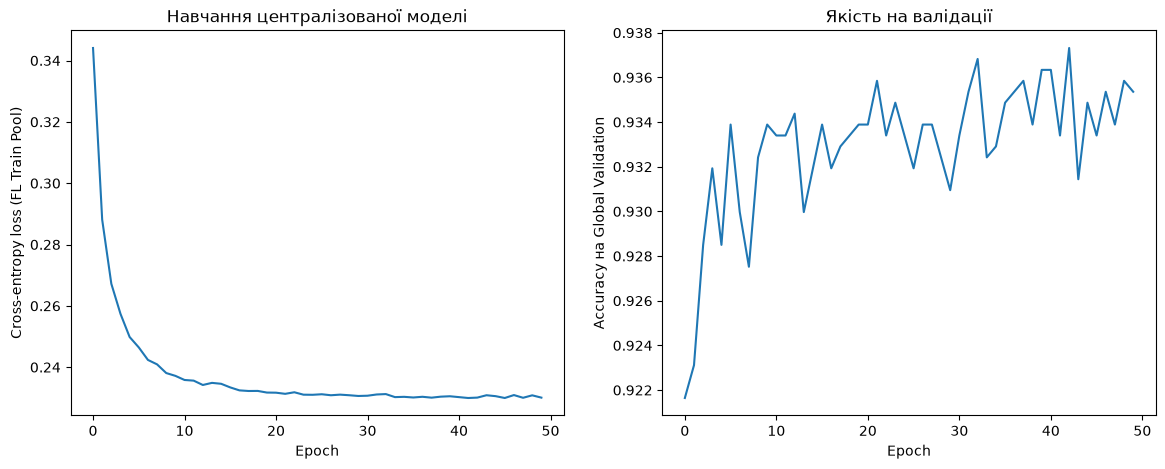

In [20]:
LR, BATCH, LAM, EPOCHS = 0.5, 64, 1e-4, 50

W_central, b_central, hist_central = fit(X_pool, y_pool, lr=LR, epochs=EPOCHS,
                                         batch_size=BATCH, lam=LAM,
                                         eval_sets=(X_val, y_val))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist_central['loss'])
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss (FL Train Pool)')
axes[0].set_title('Навчання централізованої моделі')

axes[1].plot(hist_central['val_accuracy'])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy на Global Validation')
axes[1].set_title('Якість на валідації')
plt.show()

**Висновок.** Ліворуч показано крос-ентропію на тренувальних даних, праворуч accuracy на Global Validation.

Закономірність: loss різко падає за перші 10 епох (з 0.34 до 0.24), далі виходить на плато ~0.23.
Accuracy на валідації росте до ~0.935 і після 20-ї епохи вже не покращується, а лише коливається в межах
0.930-0.937. Ці коливання є наслідком того, що міні-батчевий спуск робить шумні кроки.

Чому так: функція втрат опукла, тому модель швидко знаходить околицю мінімуму, а далі вдосконалюватись нема куди.
Розрив між тренувальною та валідаційною якістю не росте, тобто перенавчання немає.

Вплив на вибір: 50 епох достатньо, більше не потрібно.

In [21]:
# Фінальна оцінка централізованої моделі на Global Test
central_metrics = evaluate('Централізована', X_test, y_test, W_central, b_central)
pd.DataFrame([central_metrics]).round(4)

,Модель,accuracy,macro-F1,balanced acc,log-loss
0,Централізована,0.9197,0.9332,0.9332,0.2174


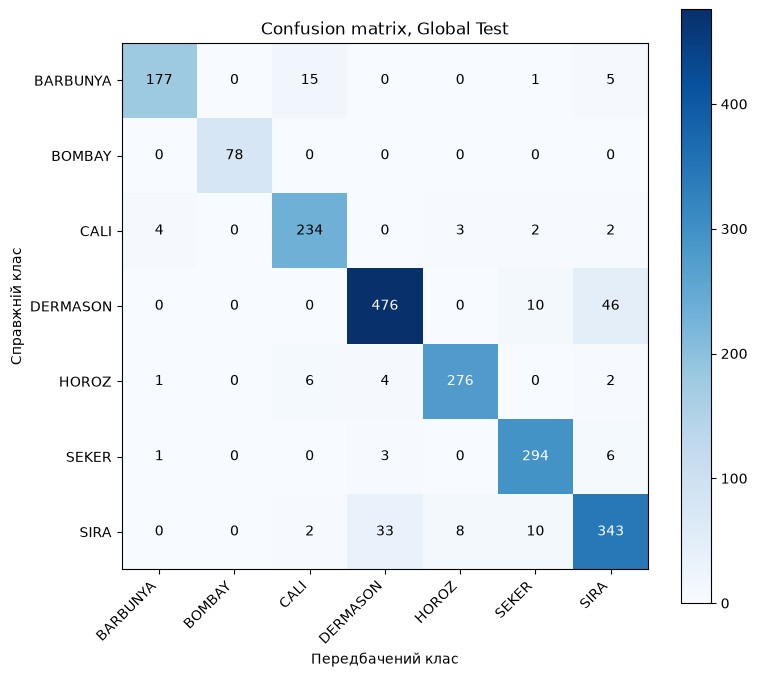

In [22]:
cm = confusion_matrix(y_test, predict(X_test, W_central, b_central))

plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(C), classes, rotation=45, ha='right')
plt.yticks(range(C), classes)
plt.xlabel('Передбачений клас')
plt.ylabel('Справжній клас')
plt.title('Confusion matrix, Global Test')
for i in range(C):
    for j in range(C):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout()
plt.show()

**Висновок щодо якості централізованої моделі на Global Test:**
accuracy 0.920, macro-F1 0.933, balanced accuracy 0.933, log-loss 0.217.

Confusion matrix показує, де саме модель помиляється:
- **BOMBAY розпізнається ідеально** (78 з 78). Це найбільші зерна, які за площею не схожі на жодні інші,
  тому лінійна межа їх легко відокремлює.
- **Основна плутанина DERMASON та SIRA** (46 і 33 помилки). Це два дрібні сорти з дуже схожими розмірами й формою.
- Менша плутанина BARBUNYA з CALI (15 помилок), теж два схожі великі сорти.

Цікаво, що macro-F1 і balanced accuracy тут **вищі** за accuracy. Так буває, коли рідкісні класи
розпізнаються краще за часті: BOMBAY має 100% recall, а найчисленніший DERMASON плутається з SIRA.

Вплив на вибір: покращити результат можна було б нелінійною моделлю або додатковими ознаками форми,
але для завдання лінійна модель дає достатню базову лінію.

## Етап 4. Розподіл даних між клієнтами та сервером

### Архітектура

```
              +---------------------------+
              |          СЕРВЕР           |
              |  Global Test (15%)        |  тільки фінальна оцінка
              |  Global Validation (15%)  |  моніторинг раундів
              |  глобальні ваги W, b      |
              +---------------------------+
                  ^ ваги            | глобальна модель
                  |                 v
   +----------+ +----------+ +----------+ +----------+ +----------+
   | Клієнт 1 | | Клієнт 2 | | Клієнт 3 | | Клієнт 4 | | Клієнт 5 |
   |   D_1    | |   D_2    | |   D_3    | |   D_4    | |   D_5    |
   +----------+ +----------+ +----------+ +----------+ +----------+
        (між клієнтами дані не перетинаються, сирі дані нікуди не передаються)
```

Сервер бачить тільки ваги, які повертають клієнти, і власні Global Validation та Global Test.
Клієнт бачить тільки свій `D_k` і глобальну модель, яку йому прислав сервер.

Між клієнтами ділимо **лише FL Train Pool** (9527 прикладів). Кожен приклад належить рівно одному клієнту.
Кількість клієнтів: K = 5. Усі розподіли відтворювані завдяки фіксованому seed.

In [23]:
K = 5   # кількість клієнтів


def split_iid(y, K, seed=SEED):
    # Перемішуємо всі індекси і ріжемо на K приблизно рівних частин
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(len(y))
    return [np.sort(part) for part in np.array_split(shuffled, K)]


def split_dirichlet(y, K, alpha, seed=SEED):
    # Для кожного класу свої пропорції розподілу між клієнтами з Dirichlet(alpha)
    rng = np.random.default_rng(seed)
    parts = [[] for _ in range(K)]
    for c in range(C):
        idx = np.where(y == c)[0]
        rng.shuffle(idx)
        proportions = rng.dirichlet([alpha] * K)
        cut_points = (np.cumsum(proportions) * len(idx)).astype(int)[:-1]
        for k, chunk in enumerate(np.split(idx, cut_points)):
            parts[k].extend(chunk)
    return [np.sort(np.array(p)) for p in parts]

In [24]:
partitions = {
    'IID': split_iid(y_pool, K),
    'Dirichlet a=5': split_dirichlet(y_pool, K, 5.0),
    'Dirichlet a=1': split_dirichlet(y_pool, K, 1.0),
    'Dirichlet a=0.3': split_dirichlet(y_pool, K, 0.3),
}

# Документування розподілу: скільки прикладів і яких класів у кожного клієнта
for name, parts in partitions.items():
    all_idx = np.concatenate(parts)
    assert len(all_idx) == len(y_pool) and len(np.unique(all_idx)) == len(y_pool)
    print(f'{name:18s} розміри клієнтів: {[len(p) for p in parts]}  сума: {sum(len(p) for p in parts)}')
print('\nПеревірка пройдена: кожен приклад належить рівно одному клієнту.')

IID                розміри клієнтів: [1906, 1906, 1905, 1905, 1905]  сума: 9527
Dirichlet a=5      розміри клієнтів: [2599, 1766, 1504, 1641, 2017]  сума: 9527
Dirichlet a=1      розміри клієнтів: [2563, 1477, 1016, 3355, 1116]  сума: 9527
Dirichlet a=0.3    розміри клієнтів: [446, 3444, 1417, 803, 3417]  сума: 9527

Перевірка пройдена: кожен приклад належить рівно одному клієнту.


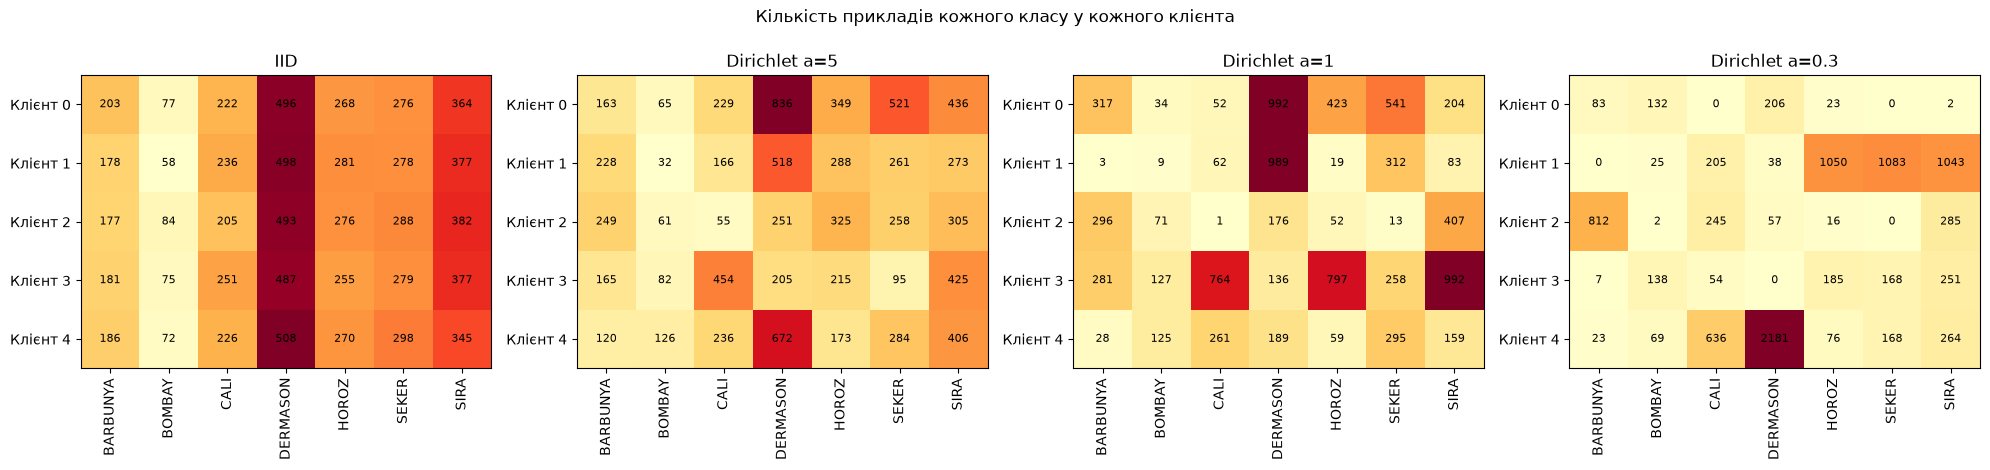

In [25]:
def class_matrix(parts):
    # таблиця: рядки клієнти, колонки класи
    return np.array([[np.sum(y_pool[p] == c) for c in range(C)] for p in parts])


fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (name, parts) in zip(axes, partitions.items()):
    matrix = class_matrix(parts)
    im = ax.imshow(matrix, cmap='YlOrRd')
    ax.set_xticks(range(C))
    ax.set_xticklabels(classes, rotation=90)
    ax.set_yticks(range(K))
    ax.set_yticklabels([f'Клієнт {k}' for k in range(K)])
    ax.set_title(name)
    for i in range(K):
        for j in range(C):
            ax.text(j, i, matrix[i, j], ha='center', va='center', fontsize=8)
plt.suptitle('Кількість прикладів кожного класу у кожного клієнта')
plt.tight_layout()
plt.show()

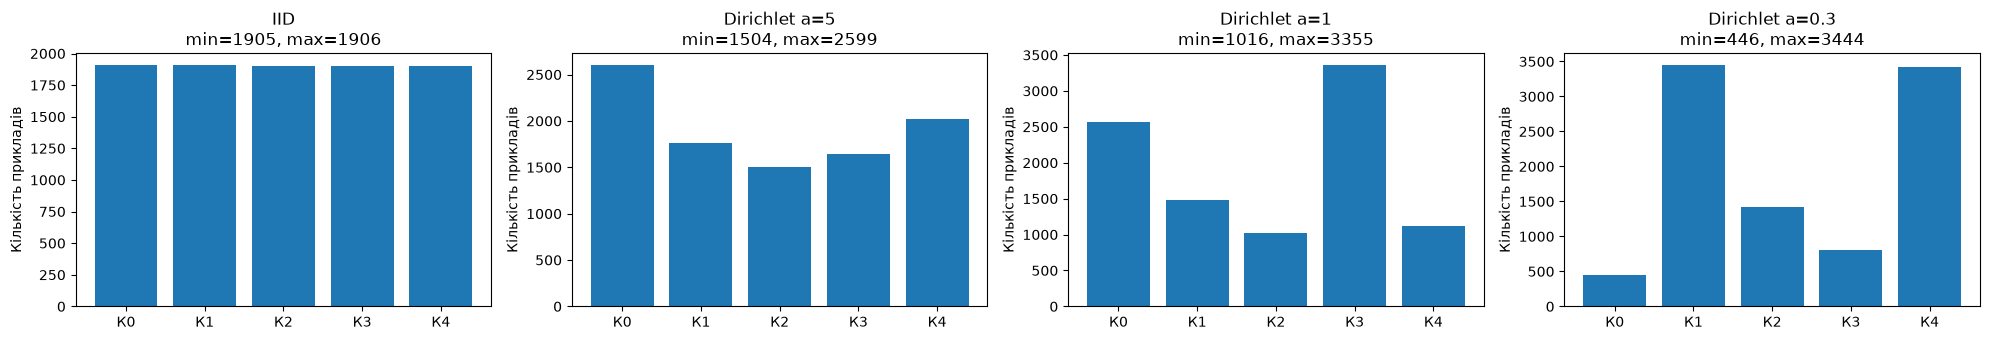

IID                клієнтів з <10 прикладами: немає; пар (клієнт, клас) з нулем прикладів: 0
Dirichlet a=5      клієнтів з <10 прикладами: немає; пар (клієнт, клас) з нулем прикладів: 0
Dirichlet a=1      клієнтів з <10 прикладами: немає; пар (клієнт, клас) з нулем прикладів: 0
Dirichlet a=0.3    клієнтів з <10 прикладами: немає; пар (клієнт, клас) з нулем прикладів: 5


In [26]:
# Розміри клієнтів і перевірка на надто малі набори
fig, axes = plt.subplots(1, 4, figsize=(20, 3.5))
for ax, (name, parts) in zip(axes, partitions.items()):
    sizes = [len(p) for p in parts]
    ax.bar(range(K), sizes)
    ax.set_xticks(range(K))
    ax.set_xticklabels([f'К{k}' for k in range(K)])
    ax.set_title(f'{name}\nmin={min(sizes)}, max={max(sizes)}')
    ax.set_ylabel('Кількість прикладів')
plt.tight_layout()
plt.show()

for name, parts in partitions.items():
    sizes = [len(p) for p in parts]
    small = [k for k, n in enumerate(sizes) if n < 10]
    matrix = class_matrix(parts)
    empty = int(np.sum(matrix == 0))
    print(f'{name:18s} клієнтів з <10 прикладами: {small if small else "немає"};'
          f' пар (клієнт, клас) з нулем прикладів: {empty}')

**Висновок щодо розподілу даних.**

Що показано: скільки прикладів кожного класу отримав кожен клієнт при чотирьох способах розподілу.

Закономірність:
- **IID:** у всіх клієнтів по ~1905 прикладів, і частки класів майже однакові (наприклад, DERMASON 487-508 у кожного).
  Кожен клієнт бачить "зменшену копію" всього датасету.
- **Dirichlet a=5:** розміри вже нерівні (1504-2599), але всі класи присутні в усіх.
- **Dirichlet a=1:** помітна нерівність: у клієнта 1 аж 989 прикладів DERMASON, а CALI лише 62; у клієнта 2 лише
  1 приклад CALI.
- **Dirichlet a=0.3:** сильна неоднорідність. Розміри від 446 до 3444, і є **5 пар (клієнт, клас) з нулем прикладів**:
  наприклад, клієнт 0 узагалі не бачив CALI і SEKER, а клієнт 1 не бачив BARBUNYA.

Чому так: параметр alpha керує "концентрацією" розподілу Діріхле. Великий alpha дає пропорції, близькі до рівних
(1/K кожному), малий alpha дає пропорції, де майже все дістається одному-двом клієнтам.

Клієнтів із менш ніж 10 прикладами немає в жодному варіанті, тому всі клієнти можуть навчатись.

Як нерівномірність впливає на якість: клієнт, який не бачив класу, ніколи не передбачить цей клас, а його локальні
ваги для цього класу тягнутимуться в мінус. Усереднення таких різнонаправлених моделей дає гіршу глобальну модель,
що ми й перевіряємо в Експерименті 1.

## Етап 5. Симуляція федеративного навчання (FedAvg)

Алгоритм одного раунду:
1. Сервер розсилає поточну глобальну модель `W, b` усім клієнтам (у нас на кожному раунді беруть участь усі K).
2. Кожен клієнт робить E локальних епох міні-батчевого градієнтного спуску **на своїх даних**, починаючи з глобальних ваг.
3. Клієнт повертає серверу тільки оновлені ваги, дані не передаються.
4. Сервер агрегує ваги як зважене середнє за кількістю прикладів:

```
W_global = sum_k (n_k / sum_j n_j) * W_k
```

5. Сервер оцінює нову глобальну модель на Global Validation.

**Питання: чому зважуємо за кількістю прикладів? Що буде при простому середньому?**

Зважування робить федеративне навчання наближенням централізованого: градієнт, порахований на всьому пулі,
це середнє градієнтів по прикладах, тому внесок клієнта має бути пропорційним його кількості прикладів `n_k`.
При простому середньому клієнт із 400 прикладами впливав би так само, як клієнт із 3400. Тоді маленькі клієнти
(чиї локальні моделі шумні й перенавчені на кількох класах) тягнули б глобальну модель на себе, і якість
падала б, особливо при нерівних розмірах, які дає Dirichlet.

In [27]:
def client_update(X_local, y_local, W_global, b_global, local_epochs, lr, batch_size, lam, seed):
    # Клієнт стартує з глобальних ваг і вчиться тільки на своїх даних
    W_k, b_k, _ = fit(X_local, y_local, lr=lr, epochs=local_epochs, batch_size=batch_size,
                      lam=lam, W_init=W_global, b_init=b_global, seed=seed)
    return W_k, b_k


def aggregate(weights_list, biases_list, n_samples):
    # FedAvg: зважене середнє за кількістю прикладів у клієнта
    coef = np.array(n_samples) / np.sum(n_samples)
    W_new = np.tensordot(coef, np.array(weights_list), axes=1)
    b_new = np.tensordot(coef, np.array(biases_list), axes=1)
    return W_new, b_new


def run_fedavg(parts, rounds=30, local_epochs=1, lr=LR, batch_size=BATCH, lam=LAM, seed=SEED):
    d = X_pool.shape[1]
    W_global = np.zeros((d, C))     # сервер ініціалізує глобальну модель
    b_global = np.zeros((1, C))
    n_samples = [len(p) for p in parts]
    history = []

    for t in range(rounds):
        client_W, client_b = [], []
        for k, idx in enumerate(parts):            # цикл по клієнтах дозволений
            W_k, b_k = client_update(X_pool[idx], y_pool[idx], W_global, b_global,
                                     local_epochs, lr, batch_size, lam, seed + 100 * t + k)
            client_W.append(W_k)
            client_b.append(b_k)

        W_global, b_global = aggregate(client_W, client_b, n_samples)
        history.append(accuracy_score(y_val, predict(X_val, W_global, b_global)))

    return W_global, b_global, history

In [28]:
ROUNDS = 30
fed_models = {}
for name, parts in partitions.items():
    W_g, b_g, hist = run_fedavg(parts, rounds=ROUNDS, local_epochs=1)
    fed_models[name] = (W_g, b_g, hist)
    print(f'{name:18s} val accuracy після {ROUNDS} раундів: {hist[-1]:.4f}')

central_val = accuracy_score(y_val, predict(X_val, W_central, b_central))
print(f'{"Централізована":18s} val accuracy: {central_val:.4f}')

IID                val accuracy після 30 раундів: 0.9295
Dirichlet a=5      val accuracy після 30 раундів: 0.9310


Dirichlet a=1      val accuracy після 30 раундів: 0.9280


Dirichlet a=0.3    val accuracy після 30 раундів: 0.9114
Централізована     val accuracy: 0.9354


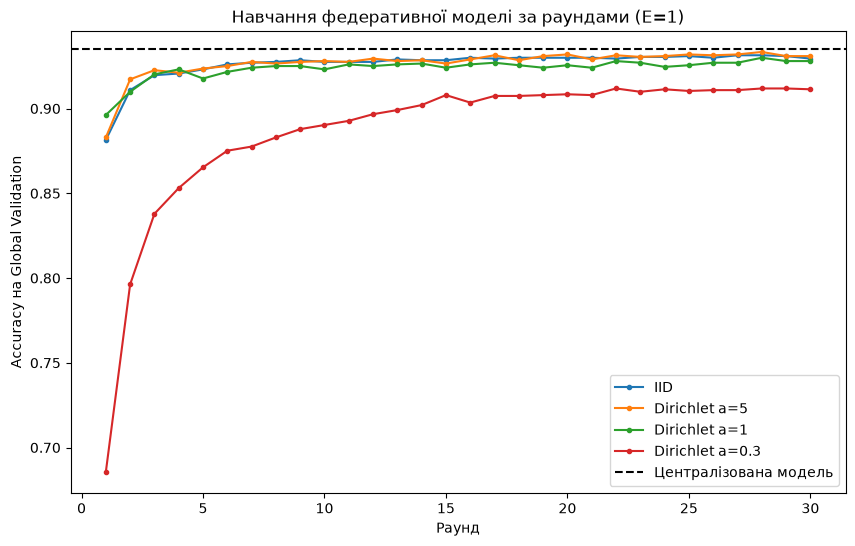

In [29]:
plt.figure(figsize=(10, 6))
for name, (_, _, hist) in fed_models.items():
    plt.plot(range(1, ROUNDS + 1), hist, marker='o', markersize=3, label=name)
plt.axhline(central_val, color='black', linestyle='--', label='Централізована модель')
plt.xlabel('Раунд')
plt.ylabel('Accuracy на Global Validation')
plt.title('Навчання федеративної моделі за раундами (E=1)')
plt.legend()
plt.show()

**Висновок.** Що показано: accuracy глобальної моделі на Global Validation після кожного раунду агрегації,
для чотирьох розподілів даних, E = 1. Пунктир це рівень централізованої моделі (0.935).

Закономірність:
- IID, a=5 і a=1 поводяться майже однаково: вже після 3-5 раундів вони на рівні 0.92, а до 30-го раунду
  доходять до 0.928-0.931, тобто майже досягають централізованої моделі.
- a=0.3 стартує набагато нижче (0.686 після першого раунду) і зростає повільно, а на 30-му раунді зупиняється
  на 0.911, помітно нижче за інших.

Чому так: при IID локальні градієнти всіх клієнтів приблизно однаково спрямовані, тому їхнє усереднення дає майже
такий самий крок, як у централізованому навчанні. При a=0.3 кожен клієнт оптимізує свою задачу (наприклад,
"відрізнити 3 класи, які я бачив"), моделі розходяться, і усереднення частково гасить прогрес.

Вплив на вибір: на однорідних даних FedAvg можна довіряти майже як централізованому навчанню, а на сильно
неоднорідних треба або більше раундів, або спеціальні методи (FedProx, SCAFFOLD).

## Етап 6. Дослідження ефектів федеративного навчання

### 6.1 Порівняння локальних, глобальної та централізованої моделей

Локальна модель клієнта це модель, навчена **тільки** на його даних, без жодної співпраці.
Усі моделі оцінюємо на одному й тому самому Global Test.

In [30]:
def compare_models(partition_name, rounds=ROUNDS, local_epochs=1):
    parts = partitions[partition_name]
    rows = []

    # 1. Локальні моделі кожного клієнта
    for k, idx in enumerate(parts):
        W_k, b_k, _ = fit(X_pool[idx], y_pool[idx], lr=LR, epochs=EPOCHS,
                          batch_size=BATCH, lam=LAM)
        row = evaluate(f'Локальна, клієнт {k} (n={len(idx)})', X_test, y_test, W_k, b_k)
        rows.append(row)

    # 2. Глобальна модель після FedAvg
    W_g, b_g, _ = run_fedavg(parts, rounds=rounds, local_epochs=local_epochs)
    rows.append(evaluate('Глобальна (FedAvg)', X_test, y_test, W_g, b_g))

    # 3. Централізована модель
    rows.append(evaluate('Централізована', X_test, y_test, W_central, b_central))
    return pd.DataFrame(rows).round(4)


print('Розподіл IID')
compare_models('IID')

Розподіл IID


,Модель,accuracy,macro-F1,balanced acc,log-loss
0,"Локальна, клієнт 0 (n=1906)",0.9167,0.9301,0.9296,0.2369
1,"Локальна, клієнт 1 (n=1906)",0.9167,0.9272,0.9266,0.2352
2,"Локальна, клієнт 2 (n=1905)",0.9158,0.9292,0.9281,0.2329
3,"Локальна, клієнт 3 (n=1905)",0.9153,0.9298,0.9302,0.2318
4,"Локальна, клієнт 4 (n=1905)",0.9177,0.9311,0.9305,0.2304
5,Глобальна (FedAvg),0.9148,0.9272,0.9261,0.2373
6,Централізована,0.9197,0.9332,0.9332,0.2174


In [31]:
print('Розподіл Dirichlet a=0.3 (сильно неоднорідний)')
compare_models('Dirichlet a=0.3')

Розподіл Dirichlet a=0.3 (сильно неоднорідний)


,Модель,accuracy,macro-F1,balanced acc,log-loss
0,"Локальна, клієнт 0 (n=446)",0.5294,0.4132,0.5631,2.3009
1,"Локальна, клієнт 1 (n=3444)",0.7356,0.6990,0.7541,1.2366
2,"Локальна, клієнт 2 (n=1417)",0.6827,0.5519,0.6156,1.6683
3,"Локальна, клієнт 3 (n=803)",0.6729,0.7100,0.7711,2.6595
4,"Локальна, клієнт 4 (n=3417)",0.8673,0.8742,0.8655,0.3542
5,Глобальна (FedAvg),0.9030,0.9151,0.9144,0.2677
6,Централізована,0.9197,0.9332,0.9332,0.2174


**Висновок щодо порівняння моделей (усе на Global Test).**

**Розподіл IID.** Локальні моделі дають accuracy 0.915-0.918, глобальна 0.915, централізована 0.920.
Різниці мінімальні. Причина: при IID кожен клієнт має 1905 прикладів, і цього вже достатньо, щоб навчити
модель із 63 параметрами. Тобто на однорідних даних федеративне навчання майже нічого не додає, але й нічого не псує.

**Розподіл Dirichlet a=0.3.** Картина зовсім інша:
- локальні моделі дуже слабкі: від 0.529 (клієнт 0, 446 прикладів, не бачив двох класів) до 0.867 (клієнт 4);
- **глобальна модель 0.903**, тобто краща за будь-яку локальну, і суттєво краща за середню локальну;
- централізована 0.920, тобто глобальна відстає від неї приблизно на 1.7 процентного пункту.

Чому так: жоден клієнт наодинці не бачить усієї картини, а FedAvg фактично "складає" їхні знання про різні класи.
Саме це і є сенс федеративного навчання: разом виходить краще, ніж поодинці, і при цьому дані нікуди не передаються.

Log-loss показує різницю ще яскравіше: у локальних моделей 0.35-2.66 (вони впевнено помиляються на класах, яких
не бачили), у глобальної 0.268.

**Відповіді на питання завдання:**
- **Чи може глобальна модель бути гіршою за централізовану?** Так, і в нас так і є (0.903 проти 0.920 при a=0.3).
- **Чи може глобальна модель бути гіршою за деякі локальні?** На Global Test у нас ні. Але це можливо, якщо
  оцінювати клієнта на його власному розподілі: клієнт, який бачить лише 2 класи, на своїх даних отримає від
  локальної моделі кращий результат, бо їй не треба розрізняти решту класів.

### 6.2 Експеримент 1. Вплив неоднорідності даних (alpha)

In [32]:
alphas = [5.0, 1.0, 0.3]
exp1 = []
for alpha in alphas:
    parts = split_dirichlet(y_pool, K, alpha)
    W_g, b_g, _ = run_fedavg(parts, rounds=ROUNDS, local_epochs=1)
    row = evaluate(f'FedAvg, alpha={alpha}', X_test, y_test, W_g, b_g)
    row['alpha'] = alpha
    exp1.append(row)

exp1_df = pd.DataFrame(exp1)
print(exp1_df.round(4).to_string(index=False))

           Модель  accuracy  macro-F1  balanced acc  log-loss  alpha
FedAvg, alpha=5.0    0.9148    0.9274        0.9262    0.2372    5.0
FedAvg, alpha=1.0    0.9148    0.9281        0.9281    0.2382    1.0
FedAvg, alpha=0.3    0.9030    0.9151        0.9144    0.2677    0.3


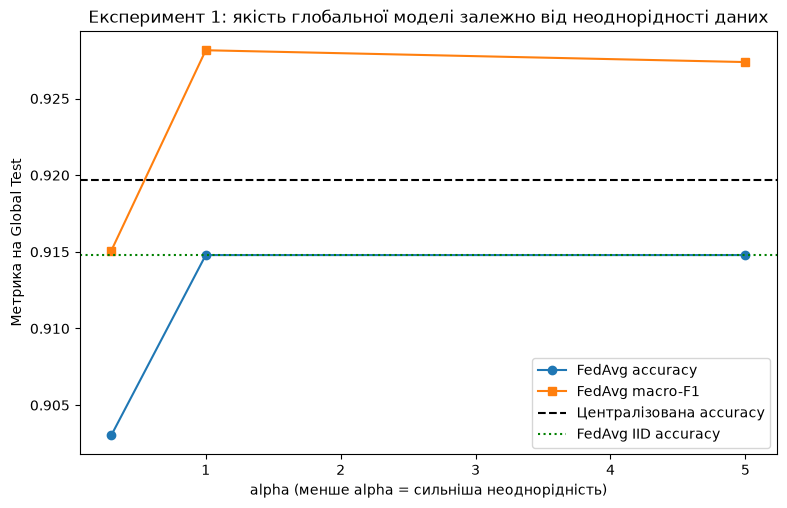

In [33]:
plt.figure(figsize=(9, 5.5))
plt.plot(exp1_df['alpha'], exp1_df['accuracy'], marker='o', label='FedAvg accuracy')
plt.plot(exp1_df['alpha'], exp1_df['macro-F1'], marker='s', label='FedAvg macro-F1')
plt.axhline(central_metrics['accuracy'], color='black', linestyle='--',
            label='Централізована accuracy')
plt.axhline(evaluate('iid', X_test, y_test, *fed_models['IID'][:2])['accuracy'],
            color='green', linestyle=':', label='FedAvg IID accuracy')
plt.xlabel('alpha (менше alpha = сильніша неоднорідність)')
plt.ylabel('Метрика на Global Test')
plt.title('Експеримент 1: якість глобальної моделі залежно від неоднорідності даних')
plt.legend()
plt.show()

**Висновок Експерименту 1.**

Що показано: метрики глобальної моделі на Global Test залежно від параметра Діріхле alpha.

| alpha | accuracy | macro-F1 | log-loss |
|---|---|---|---|
| 5 (майже IID) | 0.915 | 0.927 | 0.237 |
| 1 (помірна неоднорідність) | 0.915 | 0.928 | 0.238 |
| 0.3 (сильна неоднорідність) | 0.903 | 0.915 | 0.268 |

Закономірність: при alpha = 5 і alpha = 1 якість практично не відрізняється від IID і майже дорівнює
централізованій. Падіння починається при alpha = 0.3: accuracy втрачає ~1.2 процентного пункту, а log-loss росте.

**Чому Non-IID псує федеративне навчання:**
1. Локальні оптимуми різні. Кожен клієнт мінімізує втрати на своєму розподілі, а при різних частках класів
   мінімум зміщений. Середнє арифметичне ваг не є мінімумом жодної з цих задач.
2. Відсутні класи. Клієнт, у якого 0 прикладів CALI, під час локальних епох лише "вчиться" не передбачати CALI,
   тобто зменшує відповідні логіти. Після агрегації це псує глобальну модель для цього класу.
3. Нерівні розміри. При a=0.3 розміри від 446 до 3444, тому глобальна модель фактично визначається двома
   найбільшими клієнтами.

**Як це впливає на вибір:** якщо дані очікувано неоднорідні, треба більше раундів комунікації, менше локальних
епох (див. Експеримент 2), а в ідеалі спеціалізовані алгоритми замість простого FedAvg.

### 6.3 Експеримент 2. Вплив кількості локальних епох E

In [34]:
exp2 = []
for part_name in ['IID', 'Dirichlet a=0.3']:
    for E in [1, 5, 10]:
        W_g, b_g, hist = run_fedavg(partitions[part_name], rounds=ROUNDS, local_epochs=E)
        row = evaluate(f'{part_name}, E={E}', X_test, y_test, W_g, b_g)
        row['Розподіл'] = part_name
        row['E'] = E
        row['history'] = hist
        exp2.append(row)

exp2_df = pd.DataFrame(exp2)
print(exp2_df.drop(columns=['history']).round(4).to_string(index=False))

               Модель  accuracy  macro-F1  balanced acc  log-loss        Розподіл  E
             IID, E=1    0.9148    0.9272        0.9261    0.2373             IID  1
             IID, E=5    0.9192    0.9322        0.9313    0.2174             IID  5
            IID, E=10    0.9192    0.9320        0.9308    0.2157             IID 10
 Dirichlet a=0.3, E=1    0.9030    0.9151        0.9144    0.2677 Dirichlet a=0.3  1
 Dirichlet a=0.3, E=5    0.8986    0.9117        0.9107    0.2668 Dirichlet a=0.3  5
Dirichlet a=0.3, E=10    0.8947    0.9062        0.9049    0.2746 Dirichlet a=0.3 10


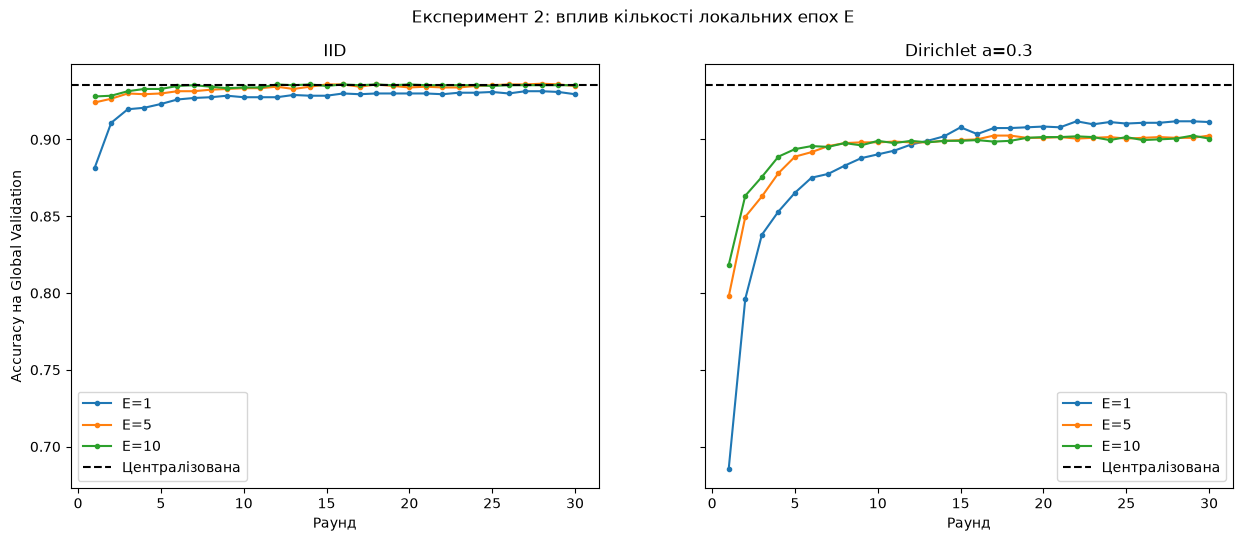

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for ax, part_name in zip(axes, ['IID', 'Dirichlet a=0.3']):
    for _, row in exp2_df[exp2_df['Розподіл'] == part_name].iterrows():
        ax.plot(range(1, ROUNDS + 1), row['history'], marker='o', markersize=3,
                label=f"E={row['E']}")
    ax.axhline(central_val, color='black', linestyle='--', label='Централізована')
    ax.set_xlabel('Раунд')
    ax.set_title(part_name)
    ax.legend()
axes[0].set_ylabel('Accuracy на Global Validation')
plt.suptitle('Експеримент 2: вплив кількості локальних епох E')
plt.show()

**Висновок Експерименту 2.**

Що показано: accuracy глобальної моделі за раундами для E = 1, 5, 10 локальних епох, окремо для IID і a=0.3.

Результати на Global Test:

| Розподіл | E=1 | E=5 | E=10 |
|---|---|---|---|
| IID | 0.9148 | 0.9192 | 0.9192 |
| Dirichlet a=0.3 | 0.9030 | 0.8986 | 0.8947 |

Закономірність **протилежна** в двох випадках:
- на **IID** збільшення E допомагає: модель швидше виходить на плато (E=5 і E=10 уже з першого раунду дають 0.93)
  і фінальна якість трохи вища;
- на **a=0.3** збільшення E шкодить: спочатку (раунди 1-10) великі E дають швидший старт, але потім криві E=5 і
  E=10 застрягають на ~0.90, тоді як E=1 обганяє їх і доходить до 0.911.

**Що таке client drift.** Це надмірне відхилення локальної моделі від глобальної під час локального навчання.
Клієнт починає з глобальних ваг, але за E епох встигає дійти до **свого** локального оптимуму. Чим більше E,
тим далі він відходить.

**Чому великий E шкодить саме на Non-IID.** При IID локальні оптимуми майже збігаються з глобальним,
тому довге локальне навчання просто наближає всіх до тієї самої точки. При Non-IID локальні оптимуми рознесені:
один клієнт тягне модель у бік "усе це DERMASON", інший у бік "усе це HOROZ". Середнє між далеко рознесеними
точками опиняється в місці, яке не є хорошим для жодного клієнта, і прогрес гальмується.

**Як це впливає на вибір гіперпараметрів:** E є компромісом між вартістю комунікації (більше E = менше раундів)
і якістю. На однорідних даних можна брати E = 5-10, на сильно неоднорідних краще E = 1-2 і більше раундів.

## Теоретичні питання

**1. Чому для багатокласової класифікації використовують softmax?**
Softmax перетворює 7 довільних чисел (логітів) на коректний розподіл ймовірностей: усі значення додатні й у сумі
дають 1. Він враховує конкуренцію між класами: збільшення логіта одного класу автоматично зменшує ймовірності інших.
Якщо натомість навчати 7 окремих сигмоїд, ймовірності не будуть узгодженими між собою.

**2. Чому крос-ентропія є природною функцією втрат для логістичної регресії?**
Вона випливає з методу максимальної правдоподібності: максимізувати ймовірність побачити наші дані це те саме,
що мінімізувати `-log(ймовірність правильного класу)`. Крім того, у парі з softmax вона дає дуже просту похідну
`P - Y` і є опуклою, тобто градієнтний спуск сходиться до глобального мінімуму. MSE тут працював би гірше:
він не опуклий у поєднанні з softmax і слабко карає впевнені помилки.

**3. Чим відрізняється Ridge від Lasso?**
Ridge (L2) додає штраф `lambda/2 * sum(w^2)`, Lasso (L1) додає `lambda * sum(|w|)`. Ridge рівномірно стискає всі
ваги до нуля, але не робить їх точно нулем, і добре працює при корельованих ознаках, розподіляючи вагу між ними.
Lasso занулює частину ваг повністю, тому його використовують як метод відбору ознак. Ridge гладкий і диференційовний
усюди, Lasso ні (у нулі).

**4. Чому b зазвичай не регуляризують?**
Зсув не множиться на ознаки, він лише задає базовий рівень логіта класу, тобто фактично враховує, наскільки клас
частий узагалі. Штрафувати його означало б штучно тягнути передбачення до рівномірного розподілу класів і вносити
зміщення, не даючи жодного виграшу в боротьбі з перенавчанням.

**5. Що таке Data Leakage?**
Ситуація, коли в процес навчання потрапляє інформація, якої в реальному використанні не буде: статистики,
пораховані на тесті, ознаки, що залежать від майбутнього, або дублікати тестових прикладів у тренувальних даних.
Наслідок: оцінка якості завищена, а в продакшені модель працює гірше.

**6. Чому тестову вибірку не можна використовувати для підбору гіперпараметрів?**
Якщо перебирати lr, lambda чи кількість епох за результатом на Test, ми поступово підлаштовуємо модель саме під
цю вибірку, і вона перестає бути незалежною. Оцінка стане оптимістичною. Саме тому підбір робимо на Global Validation,
а Test відкриваємо один раз у кінці.

**7. Чому параметри масштабування треба навчати лише на тренувальних даних?**
Середнє і std це теж параметри, вивчені з даних. Якщо рахувати їх із Test, інформація про тестовий розподіл
потрапляє в препроцесинг, тобто це Data Leakage. У реальності нові дані приходять по одному, і ми змушені
масштабувати їх статистиками, порахованими раніше на навчальних даних.

**8. Що таке федеративне навчання і які його переваги?**
Це спосіб навчити спільну модель на даних, які лишаються у власників. Замість даних передаються лише параметри
моделі. Переваги: приватність (сирі дані не покидають клієнта), відповідність регуляціям на кшталт GDPR,
економія трафіку (ваги зазвичай менші за датасет), можливість навчитись на даних, які власники ніколи б не віддали.

**9. Чому сервер не повинен отримувати сирі дані клієнтів?**
Це знищило б сенс федеративного навчання: сирі дані можуть містити персональну або комерційну таємницю, їхня
передача порушує приватність і законодавство, а також створює одну велику ціль для атаки. Модель можна навчити
й без них, через обмін вагами.

**10. Чому FedAvg зважує за кількістю прикладів?**
Щоб агрегація наближала централізоване навчання: в централізованому випадку кожен приклад має однакову вагу в
градієнті, тому клієнт із `n_k` прикладами має впливати пропорційно `n_k`.

**11. Що буде, якщо агрегувати без зважування?**
Маленькі клієнти отримають непропорційно великий вплив. Їхні локальні моделі навчені на кількох сотнях прикладів,
часто лише на частині класів, тому вони шумні й зміщені. Глобальна модель почне зміщуватись у їхній бік, якість
впаде, а на сильно Non-IID даних навчання може стати нестабільним.

**12. Що таке Non-IID дані?**
Дані, які в різних клієнтів розподілені по-різному: інші частки класів, інші діапазони ознак, інші розміри вибірок.
Порушується припущення, що всі локальні вибірки взяті з одного розподілу. Наш випадок Dirichlet з малим alpha:
у клієнта може майже не бути окремих сортів квасолі.

**13. Чому федеративне навчання погіршується на Non-IID даних?**
Кожен клієнт мінімізує свою локальну функцію втрат, а її мінімум при різних розподілах знаходиться в іншому місці,
ніж глобальний. Локальні моделі розходяться в різні боки, і їхнє усереднення не дорівнює моделі, навченій на
об'єднаних даних. Чим сильніша неоднорідність, тим більший розрив.

**14. Що таке client drift?**
Дрейф клієнта це надмірне відхилення локальної моделі від глобальної за час локального навчання. Клієнт за E епох
встигає "доїхати" до власного локального оптимуму, який на Non-IID даних далеко від глобального. Усереднення таких
моделей дає точку, яка не є хорошою ні для кого.

**15. Як кількість локальних епох впливає на глобальну модель?**
Більше E означає менше раундів зв'язку для того самого прогресу, тобто дешевшу комунікацію, і на IID даних це
зазвичай прискорює навчання. Але на Non-IID великий E підсилює client drift, і фінальна якість падає. Це видно
в Експерименті 2.

**16. Чи може глобальна модель бути гіршою за централізовану?**
Так, і зазвичай так і є. Централізована модель бачить усі дані в кожному кроці градієнта, а FedAvg лише усереднює
результати окремих локальних спусків. На IID різниця мала, на Non-IID вона помітна. Глобальна модель також може
бути гіршою за окрему локальну модель у вузькому сенсі: якщо клієнт має лише 2 класи, його локальна модель на
його власних даних буде точнішою, бо їй не треба розрізняти інші 5 класів. Але на Global Test, де є всі класи,
локальні моделі програють глобальній.

**17. Які метрики краще використовувати при дисбалансі класів?**
Accuracy оманлива: модель, що ігнорує рідкісний BOMBAY, майже не втратить у accuracy. Краще дивитись на
macro-F1 (усереднює F1 по класах з однаковою вагою) і balanced accuracy (середній recall по класах), бо вони
однаково враховують рідкісні класи. Log-loss додатково показує, наскільки модель впевнена, а confusion matrix
показує, які саме класи плутаються.

## Загальний висновок

1. **Дані.** Dry Bean Dataset: 13611 зерен, 7 класів, 16 числових ознак без пропусків. Класи незбалансовані
   (від 522 до 3546 прикладів), тому крім accuracy рахували macro-F1 і balanced accuracy. Після аналізу кореляцій
   залишили 8 ознак з 16: решта були майже дублікатами (кореляції до 0.99).

2. **Розбиття.** Спочатку відрізали Global Test (15%) і Global Validation (15%), решта 70% (9527 прикладів)
   стала FL Train Pool. Усі навчувані перетворення (scaler, відбір ознак) налаштовані без участі Test,
   тому Data Leakage немає.

3. **Модель.** Багатокласова логістична регресія (softmax) реалізована на numpy: softmax зі зсувом на максимум,
   крос-ентропія з Ridge-штрафом, аналітичні градієнти, міні-батчевий градієнтний спуск. Правильність градієнтів
   підтверджена чисельною перевіркою (розбіжність порядку 1e-10).

4. **Централізована базова модель** дала на Global Test accuracy 0.920, macro-F1 0.933, balanced accuracy 0.933,
   log-loss 0.217. Основна помилка це плутанина схожих дрібних сортів DERMASON та SIRA.

5. **Федеративне навчання.** Реалізовано FedAvg для K = 5 клієнтів: сервер розсилає ваги, клієнти вчаться локально,
   сервер агрегує зважено за кількістю прикладів. Сервер жодного разу не отримує сирих даних.

6. **Головні результати:**
   - на IID даних глобальна модель (0.915) практично дорівнює централізованій (0.920);
   - на сильно Non-IID даних (alpha = 0.3) глобальна модель падає до 0.903, але все одно значно краща за будь-яку
     локальну модель (0.529-0.867);
   - збільшення локальних епох допомагає на IID і шкодить на Non-IID через client drift.

7. **Практичний висновок.** Федеративне навчання дозволяє отримати майже таку саму якість, як централізоване,
   не збираючи дані в одному місці. Ціна цього це чутливість до неоднорідності даних: чим менш схожі дані клієнтів,
   тим більше раундів комунікації потрібно і тим обережніше треба вибирати кількість локальних епох.